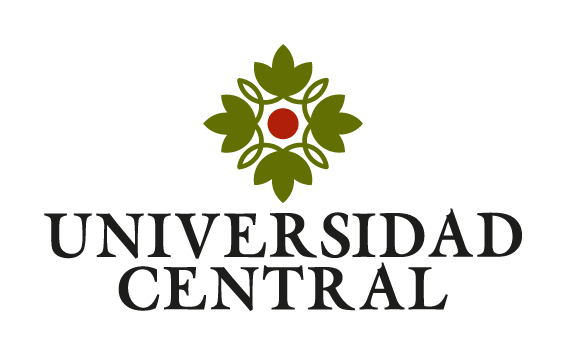

#MAESTRIA EN ANALITICA DE DATOS
---

PROCESAMIENTO DEL LENGUAJE NATURAL

Nombre: Oswaldo Salgado Gómez

Fecha: mayo 16 de 2026

Taller: Trabajo Final

# Etapa 4 (Parte A): RAG — Generación con Llama 3 y Mistral

Este notebook conecta el motor de retrieval (Etapa 3) con dos LLMs para generar **respuestas ancladas** con citas al fragmento jurídico exacto.

## Arquitectura del RAG
1. **Usuario** → consulta jurídica en lenguaje natural
2. **Retrieval** → ChromaDB devuelve top-k chunks relevantes (con coseno y filtros)
3. **Parent-document expansion** → si hay tablas, se trae el bloque padre como contexto
4. **Prompt construction** → contexto + consulta + instrucciones jurídicas
5. **Generación** → Llama 3 y Mistral generan respuestas en paralelo
6. **Output** → respuesta + citas (filename, numeral, página) + JSON con ambos resultados para comparación

## Modelos comparados
- **Llama 3** (`meta-llama/Meta-Llama-3-8B-Instruct`) — requiere token HF (gated)
- **Mistral** (`mistralai/Mistral-7B-Instruct-v0.3`) — abierto
- Ambos se cargan con cuantización 4-bit para caber en una T4 (16 GB VRAM)

## Salida

| Archivo | Contenido |
|---|---|
| `respuestas_<timestamp>.json` | Corpus completo de respuestas (entrada del dashboard) |
| `comparacion_modelos.csv` | Resumen tabular para análisis comparativo |
| `last_respuestas.json` | Apunta al JSON más reciente (cómo lo encuentra el dashboard) |

# HOJA DE RUTA A SEGUIR

0. Montar Google Drive
1. Instalar dependencias
2. Instalar Librerías
3. Configuración de Rutas
4. Autenticación HuggingFace (necesario para Llama 3)
5. Cargar Motor de Retrieval (Etapa 3)
6. Configuración de Cuantización 4-bit
7. Clase Generador (wrapper unificado para ambos modelos)
8. Construcción del Prompt Jurídico
9. Función responder_rag — orquesta retrieval + generación
10. Catálogo de consultas para comparar los modelos
11. Ejecución Comparada: Mistral → Llama 3
11.1 Mistral 7B Instruct
11.2 Llama 3 8B Instruct
12. Guardar resultados completos
13. Comparación rápida entre modelos
14. Visualización Gráfica de Rendimiento (Mistral vs Llama 3)



# 0\. Montar Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 1\. Instalar dependencias

Después de ejecutar esta celda, **reinicia el runtime** y ejecuta desde la celda 3.

In [2]:
!pip install -q "numpy<2.0" "pandas>=2.0,<2.3" \
    chromadb==0.5.5 langchain==0.3.0 langchain-community==0.3.0 \
    "transformers>=4.46,<4.50" sentencepiece tqdm \
    "accelerate>=0.34" "bitsandbytes>=0.45.2"

print('\n' + '=' * 60)
print('⚠ AHORA ES NECESARIO REINICIAS EL RUNTIME y continuar desde la celda 3')
print('  Menú: Entorno de ejecución → Reiniciar sesión')
print('=' * 60)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 1.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 584.3/584.3 kB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 40.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 64.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 66.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 75.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 125.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 28.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 47.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/

# 2\. Instalar Librerías

In [1]:
import os
import json
import sys
import time
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime
from typing import List, Dict, Optional
from tqdm.auto import tqdm
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

#3\. Configuración de Rutas

In [2]:
# Rutas
BASE_DIR        = '/content/drive/MyDrive/4_Semestre_4/PLN/Trabajo final'
RETRIEVAL_DIR   = os.path.join(BASE_DIR, 'Retrieval')
CHROMA_DIR      = os.path.join(RETRIEVAL_DIR, 'chroma_db')
GENERACION_DIR  = os.path.join(BASE_DIR, 'Generacion')
os.makedirs(GENERACION_DIR, exist_ok=True)

# Importar la clase Retriever exportada por la Etapa 3
sys.path.append(RETRIEVAL_DIR)
from retriever_utils import Retriever

print(f'Chroma:    {CHROMA_DIR}')
print(f'Salida:    {GENERACION_DIR}')
print(f'Torch:     {torch.__version__}')
print(f'GPU:       {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "NO GPU — activa T4 en Runtime"}')

Chroma:    /content/drive/MyDrive/4_Semestre_4/PLN/Trabajo final/Retrieval/chroma_db
Salida:    /content/drive/MyDrive/4_Semestre_4/PLN/Trabajo final/Generacion
Torch:     2.11.0+cu128
GPU:       Tesla T4


# 4\. Autenticación HuggingFace (necesario para Llama 3)

Si solo se usa Mistral se puede obviar esta. Si se usa Llama 3, es necesario haber aceptado los términos en https://huggingface.co/meta-llama/Meta-Llama-3-8B-Instruct y tener un token con permisos de read.

In [3]:
from google.colab import userdata
import os

os.environ["HF_TOKEN"] = userdata.get('HF_TOKEN')

print("✅ Autenticación vinculada mediante Secrets de Colab")

✅ Autenticación vinculada mediante Secrets de Colab


#5\. Cargar Motor de Retrieval (Etapa 3)

In [4]:
print('Cargando Retriever (Longformer + ChromaDB)...')
retriever = Retriever(chroma_dir=CHROMA_DIR)
print(f'✓ Retriever listo. Chunks indexados: {retriever.collection.count()}')

Cargando Retriever (Longformer + ChromaDB)...


vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/597M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/597M [00:00<?, ?B/s]

ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given


✓ Retriever listo. Chunks indexados: 1152


#6\. Configuración de Cuantización 4-bit

Llama 3 8B y Mistral 7B en fp16 ocupan ~16 GB cada uno (no caben en T4). Con 4-bit ocupan ~5 GB → ambos caben con margen.

In [6]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type='nf4',
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)
print('Configuración bnb (4-bit nf4) lista.')

Configuración bnb (4-bit nf4) lista.


#7\. Clase Generador (wrapper unificado para ambos modelos)

Cada modelo tiene su propio formato de chat template; la clase los abstrae para que el resto del notebook los use igual.

In [7]:
class GeneradorLLM:
    """Wrapper para Llama 3 / Mistral con cuantización 4-bit."""

    def __init__(self, model_id: str, nombre_corto: str):
        self.model_id = model_id
        self.nombre = nombre_corto
        print(f'\nCargando {nombre_corto} ({model_id})... esto puede tardar 3-5 min')
        self.tokenizer = AutoTokenizer.from_pretrained(model_id)
        if self.tokenizer.pad_token is None:
            self.tokenizer.pad_token = self.tokenizer.eos_token
        self.model = AutoModelForCausalLM.from_pretrained(
            model_id,
            quantization_config=bnb_config,
            device_map='auto',
            torch_dtype=torch.float16,
        )
        self.model.eval()
        print(f'✓ {nombre_corto} cargado')

    def generar(self, mensajes: list, max_new_tokens: int = 600, temperature: float = 0.2) -> str:
        """mensajes: lista de dicts [{'role': 'system'|'user'|'assistant', 'content': '...'}]"""
        prompt = self.tokenizer.apply_chat_template(
            mensajes, tokenize=False, add_generation_prompt=True
        )
        inputs = self.tokenizer(prompt, return_tensors='pt').to(self.model.device)

        with torch.no_grad():
            outputs = self.model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                temperature=temperature,
                do_sample=temperature > 0,
                top_p=0.9,
                pad_token_id=self.tokenizer.pad_token_id,
            )
        # Decodificar solo lo nuevo (no el prompt)
        respuesta = self.tokenizer.decode(
            outputs[0][inputs['input_ids'].shape[1]:],
            skip_special_tokens=True,
        )
        return respuesta.strip()

    def liberar(self):
        """Libera VRAM antes de cargar el siguiente modelo."""
        del self.model
        del self.tokenizer
        torch.cuda.empty_cache()
        print(f'✓ {self.nombre} liberado de VRAM')

#8\. Construcción del Prompt Jurídico (incluye control antialucionaciones)

El prompt instruye al LLM a:
- Responder solo con base en el contexto provisto (anti-alucinación)
- Citar siempre el `filename`, `numeral` y `página`
- Si no encuentra respuesta, decirlo explícitamente
- Mantener tono jurídico-técnico

In [8]:
SYSTEM_PROMPT = """Eres un asistente jurídico especializado en derecho ambiental colombiano, particularmente en Autos de Apertura de procedimientos sancionatorios de la Autoridad Nacional de Licencias Ambientales (ANLA).

Tu tarea es responder consultas jurídicas basándote ESTRICTAMENTE en los fragmentos de contexto que se te proporcionan. Reglas obligatorias:

1. Responde SOLO con información presente en el contexto. Si el contexto no contiene la respuesta, di explícitamente: "La información solicitada no se encuentra en los documentos consultados."
2. NO inventes hechos, fechas, numerales, normas ni decisiones.
3. Para cada afirmación relevante, cita la fuente en formato: [Documento: <filename>, Numeral: <numeral>, Página: <pag>]
4. Usa un tono jurídico-técnico, preciso y formal.
5. Si el contexto contiene tablas, identifícalas y resume su contenido relevante.
6. Estructura la respuesta así: (a) Respuesta directa, (b) Fundamentos del contexto con citas, (c) Limitaciones si aplican."""


def construir_contexto(chunks_recuperados: List[Dict], incluir_padres: bool = True) -> str:
    """Formatea los chunks recuperados como contexto numerado para el LLM."""
    bloques = []
    padres_vistos = set()

    for i, ch in enumerate(chunks_recuperados, 1):
        md = ch['metadata']
        encabezado = (
            f"[Fragmento {i}] Documento: {md['filename']} | "
            f"Tipo: {md['tipo_chunk']} | Numeral: {md['numeral']} | "
            f"Página: {md['pagina_inicio']}-{md['pagina_fin']} | "
            f"Similitud: {ch['similitud']:.3f}"
        )
        bloques.append(f"{encabezado}\n{ch['texto']}")

        # Parent-document expansion para tablas
        if incluir_padres and md['tipo_chunk'] == 'tabla':
            padre = retriever.traer_bloque_padre(ch)
            if padre and padre['bloque_id'] not in padres_vistos:
                padres_vistos.add(padre['bloque_id'])
                bloques.append(
                    f"[Contexto del Fragmento {i} — bloque padre]\n"
                    f"Numeral: {padre['numeral']} | Título: {padre['titulo']}\n"
                    f"{padre['texto_completo'][:1500]}"
                )
    return '\n\n---\n\n'.join(bloques)


def construir_mensajes(query: str, contexto: str) -> list:
    user_prompt = f"""CONTEXTO (fragmentos extraídos de los Autos de Apertura ANLA):

{contexto}

---

CONSULTA JURÍDICA:
{query}

Responde siguiendo las reglas establecidas."""
    return [
        {'role': 'system', 'content': SYSTEM_PROMPT},
        {'role': 'user', 'content': user_prompt},
    ]

print('Funciones de prompt definidas.')

Funciones de prompt definidas.


#9\. Función `responder_rag` — orquesta retrieval + generación

In [9]:
def responder_rag(
    query: str,
    generador: GeneradorLLM,
    top_k: int = 5,
    tipo_chunk: Optional[str] = None,
    filename: Optional[str] = None,
    fecha_desde: Optional[str] = None,
    fecha_hasta: Optional[str] = None,
    incluir_padres: bool = True,
    max_new_tokens: int = 600,
    temperature: float = 0.2,
) -> dict:
    """Ejecuta el pipeline RAG completo y devuelve respuesta + trazabilidad."""
    t0 = time.time()

    # 1) Retrieval
    chunks = retriever.buscar(
        query, top_k=top_k, tipo_chunk=tipo_chunk,
        filename=filename, fecha_desde=fecha_desde, fecha_hasta=fecha_hasta,
    )
    t_retrieval = time.time() - t0

    if not chunks:
        return {
            'query': query,
            'modelo': generador.nombre,
            'respuesta': 'No se encontraron fragmentos relevantes con los filtros aplicados.',
            'chunks_recuperados': [],
            'tiempo_retrieval_s': round(t_retrieval, 2),
            'tiempo_generacion_s': 0,
        }

    # 2) Construir contexto
    contexto = construir_contexto(chunks, incluir_padres=incluir_padres)
    mensajes = construir_mensajes(query, contexto)

    # 3) Generación
    t1 = time.time()
    respuesta = generador.generar(mensajes, max_new_tokens=max_new_tokens, temperature=temperature)
    t_generacion = time.time() - t1

    # 4) Devolver con trazabilidad
    return {
        'query': query,
        'modelo': generador.nombre,
        'respuesta': respuesta,
        'chunks_recuperados': [
            {
                'chunk_id': c['chunk_id'],
                'similitud': round(c['similitud'], 4),
                'tipo_chunk': c['metadata']['tipo_chunk'],
                'filename': c['metadata']['filename'],
                'numeral': c['metadata']['numeral'],
                'pagina_inicio': c['metadata']['pagina_inicio'],
                'pagina_fin': c['metadata']['pagina_fin'],
                'texto_preview': c['texto'][:200],
            } for c in chunks
        ],
        'parametros': {
            'top_k': top_k, 'tipo_chunk': tipo_chunk, 'filename': filename,
            'fecha_desde': fecha_desde, 'fecha_hasta': fecha_hasta,
            'incluir_padres': incluir_padres, 'temperature': temperature,
        },
        'tiempo_retrieval_s': round(t_retrieval, 2),
        'tiempo_generacion_s': round(t_generacion, 2),
    }

print('Función responder_rag() definida.')

Función responder_rag() definida.


#10\. Catálogo de consultas para comparar los modelos

Se define un conjunto de consultas representativas de los Autos ANLA. Cada modelo responderá cada consulta y se guardan los resultados para el dashboard.

In [10]:
CONSULTAS_EVALUACION = [
    {
        'id': 'q01',
        'pregunta': '¿Cuál es la competencia de la ANLA para iniciar un procedimiento sancionatorio ambiental?',
        'filtros': {'tipo_chunk': 'texto'},
    },
    {
        'id': 'q02',
        'pregunta': '¿Qué hechos motivan la apertura del procedimiento sancionatorio en estos autos?',
        'filtros': {'tipo_chunk': 'texto'},
    },
    {
        'id': 'q03',
        'pregunta': '¿Qué requerimientos del concepto técnico se mantienen y cuáles se modifican?',
        'filtros': {'tipo_chunk': 'tabla'},
    },
    {
        'id': 'q04',
        'pregunta': '¿Qué normas se invocan como fundamento jurídico para la apertura de la investigación?',
        'filtros': {'tipo_chunk': 'texto'},
    },
    {
        'id': 'q05',
        'pregunta': '¿Qué medidas preventivas se han adoptado o se contemplan en los autos?',
        'filtros': {'tipo_chunk': 'texto'},
    },
    {
        'id': 'q06',
        'pregunta': '¿Cuáles son los presuntos infractores identificados y qué conductas se les imputan?',
        'filtros': {'tipo_chunk': 'texto'},
    },
    {
        'id': 'q07',
        'pregunta': '¿Qué soportes documentales se exigen para acreditar el cumplimiento de las obligaciones ambientales?',
        'filtros': {'tipo_chunk': 'tabla'},
    },
]

print(f'Consultas de evaluación: {len(CONSULTAS_EVALUACION)}')
print('Personaliza este catálogo según las preguntas reales de tu tesis.')

Consultas de evaluación: 7
Personaliza este catálogo según las preguntas reales de tu tesis.


#11\. Ejecución Comparada: Mistral → Llama 3

Estrategia: Se carga un modelo a la vez en VRAM (T4 no soporta los dos a la vez incluso con 4-bit). Se ejecutan todas las consultas con Mistral, se libera  VRAM, se carga Llama 3, y se repite.

In [11]:
respuestas_completas = []   # acumula todas las respuestas de los dos modelos

## 11.1 Mistral 7B Instruct

In [12]:
gen_mistral = GeneradorLLM(
    model_id='mistralai/Mistral-7B-Instruct-v0.3',
    nombre_corto='Mistral-7B-Instruct-v0.3',
)


Cargando Mistral-7B-Instruct-v0.3 (mistralai/Mistral-7B-Instruct-v0.3)... esto puede tardar 3-5 min


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/587k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

...

model-00003-of-00003.safetensors:   0%|          | 0.00/4.55G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

✓ Mistral-7B-Instruct-v0.3 cargado


In [13]:
for consulta in tqdm(CONSULTAS_EVALUACION, desc='Mistral'):
    res = responder_rag(
        query=consulta['pregunta'],
        generador=gen_mistral,
        top_k=5,
        **consulta.get('filtros', {}),
    )
    res['consulta_id'] = consulta['id']
    respuestas_completas.append(res)

    print(f'\n[{consulta["id"]}] {consulta["pregunta"]}')
    print(f'⏱ retrieval={res["tiempo_retrieval_s"]}s | generación={res["tiempo_generacion_s"]}s')
    print(f'Respuesta:\n{res["respuesta"][:500]}...')
    print('─' * 70)

Mistral:   0%|          | 0/7 [00:00<?, ?it/s]

Input ids are automatically padded to be a multiple of `config.attention_window`: 512
ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event CollectionQueryEvent: capture() takes 1 positional argument but 3 were given
/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)



[q01] ¿Cuál es la competencia de la ANLA para iniciar un procedimiento sancionatorio ambiental?
⏱ retrieval=5.27s | generación=30.57s
Respuesta:
(a) La Autoridad Nacional de Licencias Ambientales (ANLA) tiene competencia para iniciar un procedimiento sancionatorio ambiental.

(b) La competencia de la ANLA para iniciar un procedimiento sancionatorio ambiental se deriva de la Ley 1320 de 2009, en particular de la disposición que establece su competencia para velar por el cumplimiento de las normas ambientales y sancionar a quienes incumplan dichas normas [Fragmento 1, Documento: 2464_5749_2023-07-25.pdf, Numeral: a, Página: 19-19]. Además,...
──────────────────────────────────────────────────────────────────────

[q02] ¿Qué hechos motivan la apertura del procedimiento sancionatorio en estos autos?
⏱ retrieval=0.29s | generación=33.52s
Respuesta:
(a) La apertura del procedimiento sancionatorio en los autos de los documentos 2312_589_2022-02-09, 2896_183_2024-01-18 y 2464_5749_2023-07-25 

ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event CollectionGetEvent: capture() takes 1 positional argument but 3 were given



[q03] ¿Qué requerimientos del concepto técnico se mantienen y cuáles se modifican?
⏱ retrieval=0.34s | generación=60.21s
Respuesta:
(a) Respuesta directa:
Los requerimientos que se mantienen son los siguientes:
- La Sociedad debe presentar las proyecciones de los volúmenes a transportar.
- La Sociedad debe presentar los soportes técnicos que permitan establecer que realmente el Plan de Gestión de Riesgo (PGDR), no requería actualizarse.

Los requerimientos que se modifican son los siguientes:
- La Sociedad debe presentar la información sobre las actividades autorizadas en cada acto administrativo y las ejecutadas, determinan...
──────────────────────────────────────────────────────────────────────

[q04] ¿Qué normas se invocan como fundamento jurídico para la apertura de la investigación?
⏱ retrieval=0.19s | generación=38.78s
Respuesta:
(a) La norma que se invoca como fundamento jurídico para la apertura de la investigación sancionatoria no se encuentra explícitamente en los documento

In [14]:
# Liberar VRAM antes de cargar Llama 3
gen_mistral.liberar()
del gen_mistral
import gc; gc.collect()
torch.cuda.empty_cache()
print(f'VRAM disponible tras liberar Mistral: '
      f'{torch.cuda.mem_get_info()[0] / 1e9:.2f} GB libres')

✓ Mistral-7B-Instruct-v0.3 liberado de VRAM
VRAM disponible tras liberar Mistral: 14.82 GB libres


## 11.2 Llama 3 8B Instruct

Si no tienes acceso aprobado al gated repo, salta esta sección y guarda los resultados con solo Mistral.

In [15]:
gen_llama = GeneradorLLM(
    model_id='meta-llama/Meta-Llama-3-8B-Instruct',
    nombre_corto='Llama-3-8B-Instruct',
)


Cargando Llama-3-8B-Instruct (meta-llama/Meta-Llama-3-8B-Instruct)... esto puede tardar 3-5 min


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/73.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/654 [00:00<?, ?B/s]

...

model-00003-of-00004.safetensors:   0%|          | 0.00/4.92G [00:00<?, ?B/s]

model-00004-of-00004.safetensors:   0%|          | 0.00/1.17G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/187 [00:00<?, ?B/s]

✓ Llama-3-8B-Instruct cargado


In [16]:
for consulta in tqdm(CONSULTAS_EVALUACION, desc='Llama 3'):
    res = responder_rag(
        query=consulta['pregunta'],
        generador=gen_llama,
        top_k=5,
        **consulta.get('filtros', {}),
    )
    res['consulta_id'] = consulta['id']
    respuestas_completas.append(res)

    print(f'\n[{consulta["id"]}] {consulta["pregunta"]}')
    print(f'⏱ retrieval={res["tiempo_retrieval_s"]}s | generación={res["tiempo_generacion_s"]}s')
    print(f'Respuesta:\n{res["respuesta"][:500]}...')
    print('─' * 70)

Llama 3:   0%|          | 0/7 [00:00<?, ?it/s]


[q01] ¿Cuál es la competencia de la ANLA para iniciar un procedimiento sancionatorio ambiental?
⏱ retrieval=0.99s | generación=18.38s
Respuesta:
(a) La competencia de la ANLA para iniciar un procedimiento sancionatorio ambiental es la de realizar el control y seguimiento ambiental de los expedientes, según lo establecido en el Acta No. 317 del 30 de junio de 2022, documento 2525_1964_2023-03-24.pdf, numeral 7, página 6-6.

(b) La ANLA tiene competencia para iniciar un procedimiento sancionatorio ambiental cuando se compruebe la ocurrencia de un hecho que afecte el medio ambiente, como se establece en el artículo 4.1 del documento 2330_11...
──────────────────────────────────────────────────────────────────────

[q02] ¿Qué hechos motivan la apertura del procedimiento sancionatorio en estos autos?
⏱ retrieval=0.21s | generación=15.14s
Respuesta:
(a) La apertura del procedimiento sancionatorio en estos autos se motiva por el incumplimiento de las obligaciones en el manejo de residuos sól

In [17]:
# Liberar VRAM
gen_llama.liberar()
del gen_llama
gc.collect()
torch.cuda.empty_cache()

✓ Llama-3-8B-Instruct liberado de VRAM


# 12\. Guardar resultados completos

Estos archivos se emplearán en la entrada del dashboard de Streamlit (parte B de la Etapa 4).

In [18]:
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

# 11.1 JSON completo (entrada del dashboard)
ruta_json = os.path.join(GENERACION_DIR, f'respuestas_{timestamp}.json')
with open(ruta_json, 'w', encoding='utf-8') as f:
    json.dump({
        'fecha_ejecucion': timestamp,
        'total_respuestas': len(respuestas_completas),
        'modelos': sorted(list({r['modelo'] for r in respuestas_completas})),
        'consultas': CONSULTAS_EVALUACION,
        'respuestas': respuestas_completas,
    }, f, ensure_ascii=False, indent=2)
print(f'✓ {ruta_json}')

# 11.2 CSV resumido para comparación rápida
filas = []
for r in respuestas_completas:
    filas.append({
        'consulta_id': r['consulta_id'],
        'query': r['query'],
        'modelo': r['modelo'],
        'respuesta': r['respuesta'],
        'tiempo_retrieval_s': r['tiempo_retrieval_s'],
        'tiempo_generacion_s': r['tiempo_generacion_s'],
        'n_chunks_recuperados': len(r['chunks_recuperados']),
        'similitud_top1': r['chunks_recuperados'][0]['similitud'] if r['chunks_recuperados'] else None,
        'longitud_respuesta_chars': len(r['respuesta']),
    })
df = pd.DataFrame(filas)
ruta_csv = os.path.join(GENERACION_DIR, 'comparacion_modelos.csv')
df.to_csv(ruta_csv, index=False, encoding='utf-8')
print(f'✓ {ruta_csv}')

# Crear/actualizar archivo "last" para que el dashboard sepa cuál cargar
ruta_last = os.path.join(GENERACION_DIR, 'last_respuestas.json')
with open(ruta_last, 'w', encoding='utf-8') as f:
    json.dump({'ruta_actual': os.path.basename(ruta_json)}, f)
print(f'✓ {ruta_last}')

✓ /content/drive/MyDrive/4_Semestre_4/PLN/Trabajo final/Generacion/respuestas_20260528_211610.json
✓ /content/drive/MyDrive/4_Semestre_4/PLN/Trabajo final/Generacion/comparacion_modelos.csv
✓ /content/drive/MyDrive/4_Semestre_4/PLN/Trabajo final/Generacion/last_respuestas.json


# 13\. Comparación rápida entre modelos

In [19]:
if len(df['modelo'].unique()) > 1:
    print('=' * 65)
    print('COMPARACIÓN ENTRE MODELOS — promedios')
    print('=' * 65)
    resumen = df.groupby('modelo').agg(
        tiempo_generacion_promedio=('tiempo_generacion_s', 'mean'),
        longitud_respuesta_promedio=('longitud_respuesta_chars', 'mean'),
        n_respuestas=('consulta_id', 'count'),
    ).round(2)
    print(resumen)
else:
    print('Solo se ejecutó un modelo. Para comparar, ejecuta también la otra sección.')
df

COMPARACIÓN ENTRE MODELOS — promedios
                          tiempo_generacion_promedio  \
modelo                                                 
Llama-3-8B-Instruct                            28.15   
Mistral-7B-Instruct-v0.3                       34.37   

                          longitud_respuesta_promedio  n_respuestas  
modelo                                                               
Llama-3-8B-Instruct                           1156.14             7  
Mistral-7B-Instruct-v0.3                      1145.14             7  


,consulta_id,query,modelo,respuesta,tiempo_retrieval_s,tiempo_generacion_s,n_chunks_recuperados,similitud_top1,longitud_respuesta_chars
0,q01,¿Cuál es la competencia de la ANLA para inicia...,Mistral-7B-Instruct-v0.3,(a) La Autoridad Nacional de Licencias Ambient...,5.27,30.57,5,0.9901,912
1,q02,¿Qué hechos motivan la apertura del procedimie...,Mistral-7B-Instruct-v0.3,(a) La apertura del procedimiento sancionatori...,0.29,33.52,5,0.9894,962
2,q03,¿Qué requerimientos del concepto técnico se ma...,Mistral-7B-Instruct-v0.3,(a) Respuesta directa:\nLos requerimientos que...,0.34,60.21,5,0.9839,1886
3,q04,¿Qué normas se invocan como fundamento jurídic...,Mistral-7B-Instruct-v0.3,(a) La norma que se invoca como fundamento jur...,0.19,38.78,5,0.9893,1623
4,q05,¿Qué medidas preventivas se han adoptado o se ...,Mistral-7B-Instruct-v0.3,(a) Las medidas preventivas se han adoptado o ...,0.18,27.91,5,0.9825,996
5,q06,¿Cuáles son los presuntos infractores identifi...,Mistral-7B-Instruct-v0.3,(a) Los presuntos infractores no se identifica...,0.18,9.28,5,0.9828,357
6,q07,¿Qué soportes documentales se exigen para acre...,Mistral-7B-Instruct-v0.3,(a) La información solicitada no se encuentra ...,0.09,40.33,5,0.9885,1280
7,q01,¿Cuál es la competencia de la ANLA para inicia...,Llama-3-8B-Instruct,(a) La competencia de la ANLA para iniciar un ...,0.99,18.38,5,0.9901,760
8,q02,¿Qué hechos motivan la apertura del procedimie...,Llama-3-8B-Instruct,(a) La apertura del procedimiento sancionatori...,0.21,15.14,5,0.9894,693
9,q03,¿Qué requerimientos del concepto técnico se ma...,Llama-3-8B-Instruct,(a) La Sociedad no presentó las proyecciones d...,0.09,39.56,5,0.9839,1566


In [20]:
# Ver lado a lado las respuestas a una consulta específica
consulta_ver = 'q01'
comparacion = df[df['consulta_id'] == consulta_ver]
for _, fila in comparacion.iterrows():
    print(f'\n{"═" * 70}')
    print(f'MODELO: {fila["modelo"]}  |  {fila["tiempo_generacion_s"]}s')
    print('═' * 70)
    print(fila['respuesta'])


══════════════════════════════════════════════════════════════════════
MODELO: Mistral-7B-Instruct-v0.3  |  30.57s
══════════════════════════════════════════════════════════════════════
(a) La Autoridad Nacional de Licencias Ambientales (ANLA) tiene competencia para iniciar un procedimiento sancionatorio ambiental.

(b) La competencia de la ANLA para iniciar un procedimiento sancionatorio ambiental se deriva de la Ley 1320 de 2009, en particular de la disposición que establece su competencia para velar por el cumplimiento de las normas ambientales y sancionar a quienes incumplan dichas normas [Fragmento 1, Documento: 2464_5749_2023-07-25.pdf, Numeral: a, Página: 19-19]. Además, se encuentra una práctica de la ANLA de realizar control y seguimiento ambiental a expedientes específicos, como se observa en el Acta No. 317 del 30 de junio de 2022 [Fragmento 2, Documento: 2525_1964_2023-03-24.pdf, Numeral: 7, Página: 6-6].

(c) No se presentan limitaciones específicas en el contexto consult

#14\. Visualización Gráfica de Rendimiento (Mistral vs Llama 3)

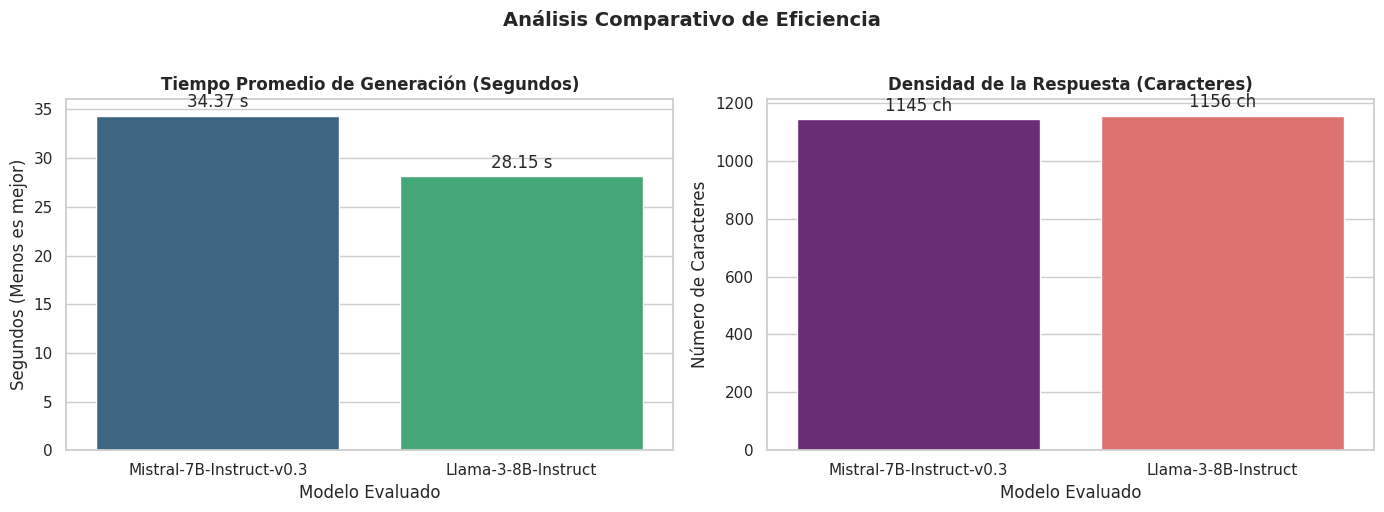

✓ Gráficos guardados con éxito en: /content/drive/MyDrive/4_Semestre_4/PLN/Trabajo final/Generacion/grafico_rendimiento_llms.png


In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

if len(df['modelo'].unique()) > 1:
    # Configurar estilo estético y profesional
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Análisis Comparativo de Eficiencia', fontsize=14, fontweight='bold', y=1.02)

    # Gráfico 1: Tiempos de Generación
    sns.barplot(
        data=df, x='modelo', y='tiempo_generacion_s',
        ax=axes[0], palette='viridis', errorbar=None, hue='modelo', legend=False
    )
    axes[0].set_title('Tiempo Promedio de Generación (Segundos)', fontsize=12, fontweight='semibold')
    axes[0].set_xlabel('Modelo Evaluado')
    axes[0].set_ylabel('Segundos (Menos es mejor)')
    for container in axes[0].containers:
        axes[0].bar_label(container, fmt='%.2f s', padding=3)

    # Gráfico 2: Longitud de la Respuesta
    sns.barplot(
        data=df, x='modelo', y='longitud_respuesta_chars',
        ax=axes[1], palette='magma', errorbar=None, hue='modelo', legend=False
    )
    axes[1].set_title('Densidad de la Respuesta (Caracteres)', fontsize=12, fontweight='semibold')
    axes[1].set_xlabel('Modelo Evaluado')
    axes[1].set_ylabel('Número de Caracteres')
    for container in axes[1].containers:
        axes[1].bar_label(container, fmt='%.0f ch', padding=3)

    plt.tight_layout()

    # Guardar gráfico  en la carpeta de Generación
    ruta_grafico = os.path.join(GENERACION_DIR, 'grafico_rendimiento_llms.png')
    plt.savefig(ruta_grafico, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✓ Gráficos guardados con éxito en: {ruta_grafico}")
else:
    print("Gráficos omitidos: Se requiere la ejecución de ambos modelos para generar el contraste visual.")